<a href="https://colab.research.google.com/github/opu483/Energy-Consumption-Prediction/blob/main/Energy_Consumption_Prediction_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Install Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow.keras import layers

Load Dataset

In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("Electric Vehicle Trip Energy Consumption Data.csv")

print(df.head())
print(df.describe())

   Trip Energy Consumption  Vehicle ID  Trip Distance  Time of Day  \
0                    0.672           1              6    10.333333   
1                    0.896           1              6    16.000000   
2                    1.344           1              7    16.090909   
3                    1.344           1              8    19.000000   
4                    0.896           1              6    14.166667   

   Day of the Week   Longitude   Latitude       Speed   Current  \
0                4  121.497948  31.281574  246.000000  2.583348   
1                4  121.587564  31.256070  393.714286  2.985729   
2                2  121.576968  31.262034  192.000000  2.354560   
3                5  121.549709  31.257796  369.240000  1.540015   
4                6  121.582280  31.215030  413.450617  9.659892   

   Total Voltage  Maximum Cell Temperature of Battery  \
0     308.283333                            31.000000   
1     304.485714                            29.000000   
2    

Dataset Information

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10151 entries, 0 to 10150
Data columns (total 13 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Trip Energy Consumption              10151 non-null  float64
 1   Vehicle ID                           10151 non-null  int64  
 2   Trip Distance                        10151 non-null  int64  
 3   Time of Day                          10151 non-null  float64
 4   Day of the Week                      10151 non-null  int64  
 5   Longitude                            10151 non-null  float64
 6   Latitude                             10151 non-null  float64
 7   Speed                                10151 non-null  float64
 8   Current                              10151 non-null  float64
 9   Total Voltage                        10151 non-null  float64
 10  Maximum Cell Temperature of Battery  10151 non-null  float64
 11  Minimum Cell Temperature of 

Null value

In [4]:
df.isnull().sum()

,0
Trip Energy Consumption,0
Vehicle ID,0
Trip Distance,0
Time of Day,0
Day of the Week,0
Longitude,0
Latitude,0
Speed,0
Current,0
Total Voltage,0


In [5]:
df = df.dropna()

In [6]:
df["Time of Day"] = pd.to_datetime(df["Time of Day"])

df["hour"] = df["Time of Day"].dt.hour
df["minute"] = df["Time of Day"].dt.minute

df["hour_sin"] = np.sin(2*np.pi*df["hour"]/24)
df["hour_cos"] = np.cos(2*np.pi*df["hour"]/24)

df = df.drop(columns=["Time of Day","hour","minute"])

In [7]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["Day of the Week"] = le.fit_transform(df["Day of the Week"])

In [8]:
df = df.drop(columns=["Vehicle ID"])

Target (Y)

In [9]:
X = df.drop("Trip Energy Consumption", axis=1)
y = df["Trip Energy Consumption"]

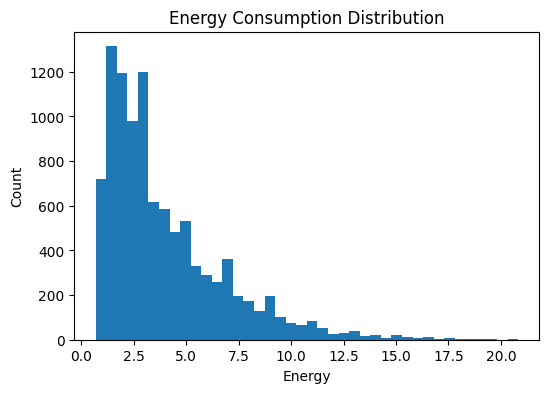

In [10]:
plt.figure(figsize=(6,4))

plt.hist(df["Trip Energy Consumption"], bins=40)

plt.title("Energy Consumption Distribution")
plt.xlabel("Energy")
plt.ylabel("Count")

plt.show()

Vizualization

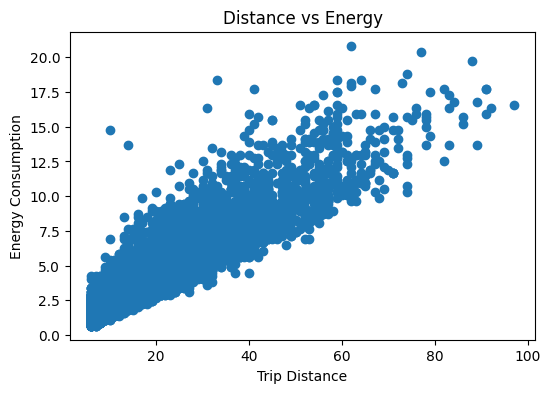

In [11]:
plt.figure(figsize=(6,4))

plt.scatter(df["Trip Distance"], df["Trip Energy Consumption"])

plt.xlabel("Trip Distance")
plt.ylabel("Energy Consumption")

plt.title("Distance vs Energy")

plt.show()

Correlation Heatmap

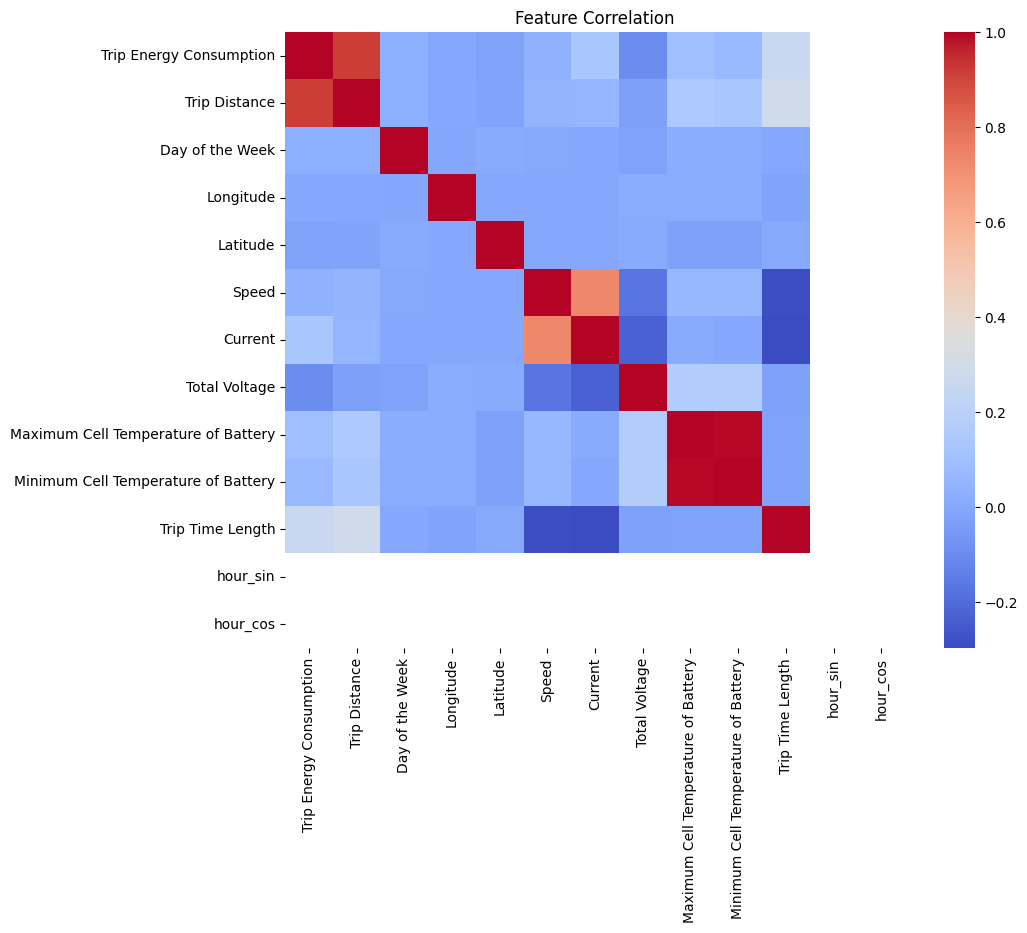

In [12]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(), cmap="coolwarm")

plt.title("Feature Correlation")

plt.show()

Train/Test Split

In [13]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.25, random_state=42
)


XGBoost

In [16]:
import xgboost as xgb

xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    random_state=42
)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

Performance

In [17]:
r2_xgb = r2_score(y_test, xgb_pred)
rmse_xgb = np.sqrt(mean_squared_error(y_test, xgb_pred))
mae_xgb = mean_absolute_error(y_test, xgb_pred)

print("\nXGBoost Performance:")
print("R2:", r2_xgb)
print("RMSE:", rmse_xgb)
print("MAE:", mae_xgb)



XGBoost Performance:
R2: 0.8867031514602668
RMSE: 0.9569503592391795
MAE: 0.6254355175337329


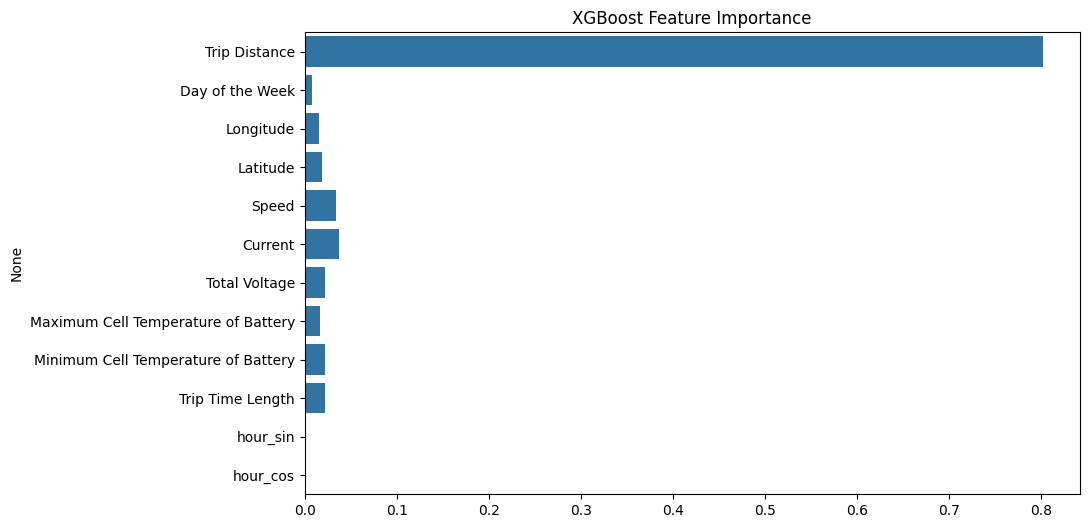

In [19]:
importances = xgb_model.feature_importances_
feature_names = X.columns

plt.figure(figsize=(10,6))
sns.barplot(x=importances, y=feature_names)
plt.title("XGBoost Feature Importance")
plt.show()

Visualization

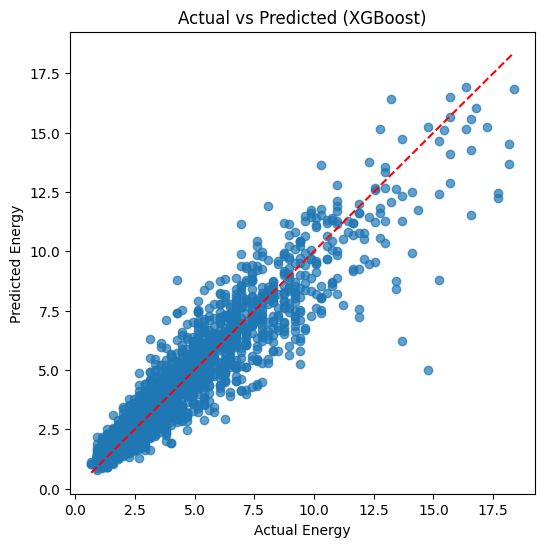

In [20]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, xgb_pred, alpha=0.7)
plt.xlabel("Actual Energy")
plt.ylabel("Predicted Energy")
plt.title("Actual vs Predicted (XGBoost)")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

save model

In [21]:
import pickle

# Save XGBoost model
with open("xgb_model.pkl", "wb") as f:
    pickle.dump(xgb_model, f)

# Save scaler
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

# Save label encoder
with open("labelencoder.pkl", "wb") as f:
    pickle.dump(le, f)

print("Model, scaler, and encoder saved as .pkl files!")

Model, scaler, and encoder saved as .pkl files!
